In [1]:
!pip install datasets
!pip install -U datasets
!pip install tiktoken
!pip install torch

In [2]:
from datasets import load_dataset

ds = load_dataset("roneneldan/TinyStories")

In [3]:
import tiktoken
import os
import numpy as np
from tqdm.auto import tqdm

encoder = tiktoken.get_encoding("gpt2")

def process(example):
  ids = encoder.encode_ordinary(example["text"])
  output = {'ids': ids, 'len': len(ids)}
  return output


if not os.path.exists("train.bin"):
  tokenized = ds.map(
      process,
      remove_columns = ["text"],
      desc = "tokenizing the splits",
      num_proc = 8,
  )

  for split,dset in tokenized.items():
    arr_len = np.sum(dset['len'], dtype = np.uint64)
    filename = f'{split}.bin'
    dtype = np.uint16
    arr = np.memmap(filename, dtype = dtype, mode = "w+", shape = (arr_len,))
    total_batches = 1024

    idx = 0
    for batch_idx in tqdm(range(total_batches), desc = f'writing {filename}'):
      batch = dset.shard(num_shards = total_batches, index = batch_idx, contiguous = True).with_format('numpy')
      arr_batch = np.concatenate(batch['ids'])
      arr[idx:idx+len(arr_batch)] = arr_batch
      idx += len(arr_batch)
    arr.flush()

In [4]:
import torch

def compute_rope_params(head_dim, theta_base = 10_000, context_length = 4096,dtype = torch.float32):
  assert head_dim%2==0, "Embedding dimension must be even"

  inv_freq = 1.0 / (theta_base ** (torch.arange(0,head_dim,2,dtype = dtype)[: (head_dim//2)].float()/head_dim))

  positions = torch.arange(context_length,dtype = dtype)
  angles = positions[:,None]  * inv_freq[None, :]

  angles = torch.cat([angles,angles],dim=1)

  cos = torch.cos(angles)
  sin = torch.sin(angles)
  return cos,sin

def apply_rope(x,cos,sin):
  batch_size, num_heads, seq_length ,  head_dim = x.shape
  assert head_dim%2==0 , "Head Dimension must be even"

  x1 = x[..., : head_dim//2]
  x2 = x[..., head_dim//2:]

  cos = cos[:seq_length,:].unsqueeze(0).unsqueeze(0)
  sin = sin[:seq_length,:].unsqueeze(0).unsqueeze(0)

  rotated = torch.cat((-x2,x1),dim=-1)
  x_rotated = (x*cos) + (rotated*sin)

  return x_rotated.to(dtype = x.dtype)


In [5]:
import torch
def get_batch(split):
  if split=="train":
    data = np.memmap('train.bin',dtype=np.uint16,mode='r')
  else:
    data = np.memmap('validation.bin',dtype=np.uint16,mode = 'r')
  ix = torch.randint(0, len(data)-block_size, (batch_size,))
  x = torch.stack([torch.from_numpy((data[i:i+block_size]).astype(np.int64))for i in ix])
  y = torch.stack([torch.from_numpy((data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])
  if device_type =="cuda":
    x,y = x.pin_memory().to(device,non_blocking = True) , y.pin_memory().to(device,non_blocking = True)
  else:
    x,y = x.to(device), y.to(device)
  return x,y

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from dataclasses import dataclass
import numpy as np
from tqdm.auto import tqdm
from contextlib import nullcontext
import os

class RMSNorm(nn.Module):
  def __init__(self,emb_dim,eps=1e-6,bias = False):
    super().__init__()
    self.eps = eps
    self.scale = nn.Parameter(torch.zeros(emb_dim))
    self.shift = nn.Parameter(torch.zeros(emb_dim)) if bias else None

  def forward(self,x):
    input_dtype = x.dtype
    x_f = x.float()
    var = x_f.pow(2).mean(dim=-1,keepdim = True)
    x_norm = x_f * torch.rsqrt(var + self.eps)
    out = x_norm * (1.0 + self.scale.float())

    if self.shift is not None:
      out = out + self.shift.float()

    return out.to(input_dtype)

class GroupedQueryAttention(nn.Module):
  def __init__(
      self,d_in, num_heads, num_kv_groups, head_dim = None,qk_norm = False,
      query_pre_attn_scalar = None, dtype =None,
  ):
    super().__init__()
    assert num_heads % num_kv_groups == 0 , "num_heads must be divisible by num_kv_groups"

    self.num_heads = num_heads
    self.num_kv_groups = num_kv_groups
    self.group_size = num_heads // num_kv_groups

    if head_dim is None:
      assert d_in % num_heads == 0 , "d_in must be divisible by num_heads"
      head_dim = d_in //num_heads

    self.head_dim = head_dim
    self.d_out = num_heads * head_dim

    self.w_query = nn.Linear(d_in,self.d_out , bias = False,dtype= dtype)
    self.w_key = nn.Linear(d_in,num_kv_groups * head_dim , bias = False,dtype= dtype)
    self.w_value = nn.Linear(d_in,num_kv_groups * head_dim , bias = False,dtype= dtype)

    self.out_proj = nn.Linear(self.d_out , d_in , bias = False, dtype= dtype)

    if qk_norm:
      self.q_norm = RMSNorm(head_dim , eps = 1e-6)
      self.k_norm = RMSNorm(head_dim , eps = 1e-6)
    else:
      self.q_norm = self.k_norm = None

    if query_pre_attn_scalar is not None:
      self.scaling = (query_pre_attn_scalar) ** -0.5
    else:
      self.scaling = (head_dim) ** -0.5

  def forward(self,x, mask,cos,sin):
    b , num_tokens, _  = x.shape

    queries = self.w_query(x)
    keys = self.w_key(x)
    values = self.w_value(x)


    queries = queries.view(b, num_tokens , self.num_heads,self.head_dim).transpose(1,2)
    keys = keys.view(b,num_tokens, self.num_kv_groups,self.head_dim).transpose(1,2)
    values = values.view(b,num_tokens , self.num_kv_groups,self.head_dim).transpose(1,2)

    if self.q_norm:
      queries = self.q_norm(queries)
    if self.k_norm:
      keys = self.k_norm(keys)

    queries = apply_rope(queries,cos,sin)
    keys = apply_rope(keys,cos,sin)

    keys = keys.repeat_interleave(self.group_size,dim = 1)
    values = values.repeat_interleave(self.group_size, dim =1)

    queries = queries * self.scaling

    attn_scores = queries @ keys.transpose(2,3)
    attn_scores = attn_scores.masked_fill(mask,-torch.inf)
    attn_weights = torch.softmax(attn_scores,dim=-1)

    context = (attn_weights @ values).transpose(1,2).reshape(b,num_tokens,self.d_out)
    return self.out_proj(context)

class FeedForward(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.fc1 = nn.Linear(cfg["emb_dim"],cfg["hidden_dim"],dtype = cfg["dtype"],bias = False)
    self.fc2 = nn.Linear(cfg["emb_dim"],cfg["hidden_dim"],dtype = cfg["dtype"],bias = False)
    self.fc3 = nn.Linear(cfg["hidden_dim"],cfg["emb_dim"],dtype = cfg["dtype"],bias = False)

  def forward(self,x):
    x_fc1 = self.fc1(x)
    x_fc2 = self.fc2(x)
    x = nn.functional.gelu(x_fc1,approximate = "tanh") * x_fc2
    return self.fc3(x)

class TransformerBlock(nn.Module):
  def __init__(self,cfg:dict,attn_type:str):
    super().__init__()
    self.attn_type = attn_type
    self.attn = GroupedQueryAttention(
        d_in = cfg["emb_dim"],
        num_heads = cfg["n_heads"],
        num_kv_groups = cfg["n_kv_groups"],
        head_dim = cfg["head_dim"],
        qk_norm = cfg["qk_norm"],
        query_pre_attn_scalar = cfg["query_pre_attn_scalar"],
        dtype = cfg["dtype"],
    )

    self.ff = FeedForward(cfg)
    self.input_layernorm = RMSNorm(cfg["emb_dim"],eps = 1e-6)
    self.post_attention_layernorm = RMSNorm(cfg["emb_dim"],eps = 1e-6)
    self.pre_feedforward_layernorm = RMSNorm(cfg["emb_dim"],eps = 1e-6)
    self.post_feedforward_layernorm = RMSNorm(cfg["emb_dim"] , eps = 1e-6)

  def forward(self,x,mask_global,mask_local,cos_global,sin_global,cos_local,sin_local):
    shortcut = x
    x = self.input_layernorm(x)

    if self.attn_type =="sliding_attention":
      attn_mask = mask_local
      cos = cos_local
      sin = sin_local
    else:
      attn_mask = mask_global
      cos = cos_global
      sin = sin_global

    x_attn = self.attn(x,attn_mask,cos,sin)
    x_attn = self.post_attention_layernorm(x_attn)
    x = shortcut + x_attn

    shortcut = x
    x_ffn = self.pre_feedforward_layernorm(x)
    x_ffn = self.ff(x_ffn)
    x_ffn = self.post_feedforward_layernorm(x_ffn)
    x = shortcut + x_ffn
    return x

class Gemma3Model(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    assert cfg["layer_types"] is not None and len(cfg["layer_types"]) == cfg["n_layers"]

    self.tok_emb = nn.Embedding(cfg["vocab_size"],cfg["emb_dim"],dtype = cfg["dtype"])

    self.blocks = nn.ModuleList([
        TransformerBlock(cfg,attn_type) for attn_type in cfg["layer_types"]
    ])


    self.final_norm = RMSNorm(cfg["emb_dim"],eps = 1e-6)
    self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"],bias = False, dtype = cfg["dtype"])
    self.cfg = cfg

    cos_local , sin_local = compute_rope_params(
        head_dim = cfg["head_dim"],
        theta_base = cfg["rope_local_base"],
        context_length = cfg["context_length"],
        dtype = torch.float32,
    )

    cos_global , sin_global = compute_rope_params(
        head_dim = cfg["head_dim"],
        theta_base = cfg["rope_global_base"],
        context_length = cfg["context_length"],
        dtype = torch.float32,
    )
    self.register_buffer("cos_local", cos_local , persistent = False)
    self.register_buffer("sin_local", sin_local , persistent = False)
    self.register_buffer("cos_global", cos_global , persistent = False)
    self.register_buffer("sin_global", sin_global , persistent = False)
  
  def _create_masks(self,seq_len, device):
    ones = torch.ones((seq_len,seq_len), dtype=torch.bool, device=device)
    mask_global = torch.triu(ones, diagonal=1)
    mask_local = torch.triu(ones, diagonal=1) | torch.tril(ones, diagonal=-self.cfg["sliding_window"])  
    return mask_global, mask_local

    
  def forward(self,input_ids,targets = None):
    b,seq_len  = input_ids.shape
    x = self.tok_emb(input_ids) * (self.cfg["emb_dim"]**0.5)
    mask_global , mask_local = self._create_masks(seq_len,x.device)

    for block in self.blocks:
      x = block(
          x,
          mask_global = mask_global,
          mask_local= mask_local,
          cos_global = self.cos_global,
          sin_global = self.sin_global,
          cos_local = self.cos_local,
          sin_local = self.sin_local,
      )
    x = self.final_norm(x)
    logits = self.out_head(x.to(self.cfg["dtype"]))
    loss = None
    if targets is not None:
      loss = F.cross_entropy(logits.reshape(-1,logits.size(-1)),targets.reshape(-1))
    return logits,loss


  @torch.no_grad()
  def generate(self,idx,max_new_tokens,temperature = 1.0,top_k = None):
    for _ in range(max_new_tokens):
      ctx_len = self.cfg["context_length"]
      idx_cond = idx if idx.size(1) <= ctx_len else idx[:,-ctx_len:]
      logits , _ = self(idx_cond)
      logits = logits[:,-1,:]/ temperature
      if top_k is not None:
        v , _ = torch.topk(logits, min(top_k,logits.size(-1)))
        logits[logits< v[:,[-1]]] = float('-inf')
      probs = F.softmax(logits,dim=-1)
      idx_next = torch.multinomial(probs,num_samples = 1)
      idx  = torch.cat((idx,idx_next),dim=1)
    return idx




In [7]:
GEMMA3_CONFIG_270M= {
    "vocab_size": 50257,
    "context_length": 32768,
    "emb_dim": 640,
    "n_heads": 4,
    "n_layers": 18,
    "hidden_dim": 2048,
    "head_dim": 256,
    "qk_norm": True,
    "n_kv_groups": 1,
    "rope_local_base": 10000.0,
    "rope_global_base": 1000000.0,
    "sliding_window": 4096,
    "layer_types": [
        "sliding_attention",
        "sliding_attention",
        "sliding_attention",
        "sliding_attention",
        "sliding_attention",
        "sliding_attention",
        "sliding_attention",
        "full_attention",
        "sliding_attention",
        "sliding_attention",
        "sliding_attention",
        "sliding_attention",
        "sliding_attention",
        "sliding_attention",
        "sliding_attention",
        "full_attention",
        "sliding_attention",
        "sliding_attention",
    ],
    "dtype": torch.bfloat16,
    "query_pre_attn_scalar": 256,
}

torch.manual_seed(123)
model = Gemma3Model(GEMMA3_CONFIG_270M)

In [8]:
def estimate_loss(model):
  out = {}
  model.eval()
  with torch.inference_mode():
    for split in ['train','val']:
      losses = torch.zeros(eval_iters)
      for k in range(eval_iters):
        x,y = get_batch(split)
        with ctx:
          logits, loss = model(x,y)
        losses[k] = loss.item()
      out[split] = losses.mean()
  model.train()
  return out

In [9]:
import torch
from contextlib import nullcontext
learning_rate = 1e-4
max_iters = 150000
warmup_steps = 1000
min_lr = 5e-4
eval_iters = 500
batch_size = 32
block_size = 128

gradient_accumulation_steps = 32

device =  "cuda" if torch.cuda.is_available() else "cpu"
device_type = 'cuda' if 'cuda' in device else 'cpu'

dtype = "bfloat16" if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else "float16"
ptdtype = {'float32': torch.float32,'bfloat16': torch.bfloat16,'float16': torch.float16}[dtype]

ctx = nullcontext() if device_type =="cpu" else torch.amp.autocast(device_type = device_type,dtype = ptdtype)

torch.set_default_device(device)
torch.manual_seed(42)

In [10]:
from torch.optim.lr_scheduler import LinearLR, SequentialLR, CosineAnnealingLR

optimizer = torch.optim.AdamW(model.parameters() , lr = learning_rate, betas = (0.9,0.95),weight_decay = 0.1, eps = 1e-9)

scheduler_warmup = LinearLR(optimizer,total_iters = warmup_steps)
scheduler_decay = CosineAnnealingLR(optimizer,T_max = max_iters - warmup_steps,eta_min = min_lr)
scheduler = SequentialLR(optimizer, schedulers = [scheduler_warmup,scheduler_decay],milestones = [warmup_steps])

scaler = torch.amp.GradScaler('cuda', enabled=(dtype == 'float16'))

In [11]:
import os
import torch
from tqdm import tqdm

best_model_params_path = "best_model_params.pt"
interrupt_checkpoint_path = "resume_checkpoint.pt"

start_epoch = 0
best_val_loss = float('inf')
train_loss_list, validation_loss_list = [], []

model = model.to(device)

if os.path.exists(interrupt_checkpoint_path):
    print(f"Found interrupt checkpoint. Resuming training...")
    checkpoint = torch.load(interrupt_checkpoint_path)
    
    # Restore model, optimizer, scaler, and scheduler states
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scaler.load_state_dict(checkpoint['scaler_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    
    start_epoch = checkpoint['epoch'] + 1
    best_val_loss = checkpoint['best_val_loss']
    train_loss_list = checkpoint['train_loss_list']
    validation_loss_list = checkpoint['validation_loss_list']
    print(f"Successfully resumed. Starting from iteration {start_epoch}.")
else:
    print("No resume checkpoint found. Starting from scratch.")


try:
    for epoch in tqdm(range(start_epoch, max_iters), initial=start_epoch, total=max_iters):
        
        if epoch % eval_iters == 0 and epoch != 0:
            model.eval() 
            losses = estimate_loss(model)
            model.train() 
            
            print(f"Epoch {epoch}: train_loss {losses['train']:.4f} , val_loss {losses['val']:.4f}")
            print(f"The Current learning rate: {optimizer.param_groups[0]['lr']:.5f}")
            
            train_loss_list.append(losses['train'].item())
            validation_loss_list.append(losses['val'].item())

            if losses['val'] < best_val_loss:
                best_val_loss = losses['val']
                torch.save(model.state_dict(), best_model_params_path)

        x, y = get_batch('train')
        x, y = x.to(device), y.to(device)

        with ctx:
            logits, loss = model(x, y)
            loss = loss / gradient_accumulation_steps
            
        scaler.scale(loss).backward()

        if ((epoch + 1) % gradient_accumulation_steps == 0) or (epoch + 1 == max_iters):
            
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
            
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            
            scheduler.step()

except KeyboardInterrupt:
    print(f"\n[!] Training interrupted by user at iteration {epoch}.")
    print("Saving full state to resume later...")

    
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scaler_state_dict': scaler.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_val_loss': best_val_loss,
        'train_loss_list': train_loss_list,
        'validation_loss_list': validation_loss_list
    }, interrupt_checkpoint_path)
    
    print("State saved! You can now run inference.")

Found interrupt checkpoint. Resuming training...


Successfully resumed. Starting from iteration 50891.


 34%|███▍      | 51000/150000 [00:18<4:16:53,  6.42it/s] 

Epoch 51000: train_loss 2.8696 , val_loss 2.8666
The Current learning rate: 0.00010


 34%|███▍      | 51500/150000 [02:38<4:09:27,  6.58it/s]  

...

Epoch 73500: train_loss 2.7347 , val_loss 2.7302
The Current learning rate: 0.00010


 49%|████▉     | 74001/150000 [1:42:57<375:26:44, 17.78s/it]

Epoch 74000: train_loss 2.7282 , val_loss 2.7381
The Current learning rate: 0.00010


 49%|████▉     | 74023/150000 [1:43:00<5:38:21,  3.74it/s]  



[!] Training interrupted by user at iteration 74023.
Saving full state to resume later...
State saved! You can now run inference.


  Using cached matplotlib-3.10.8-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
  Using cached pillow-12.1.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.7 MB)
Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (362 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17

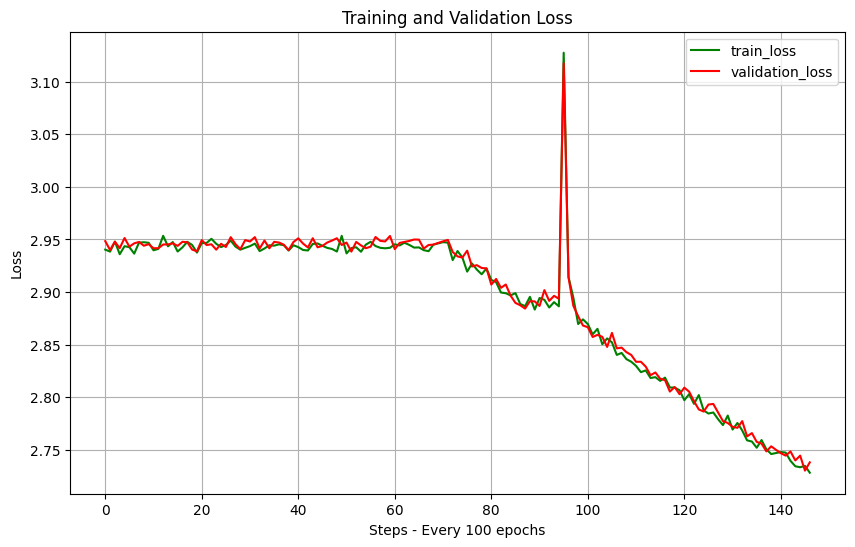

In [12]:
!pip install matplotlib
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6)) 
plt.plot(train_loss_list, 'g', label='train_loss')
plt.plot(validation_loss_list, 'r', label='validation_loss')

plt.title("Training and Validation Loss")
plt.xlabel("Steps - Every 100 epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True) 
plt.show()

In [13]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"

model = Gemma3Model(GEMMA3_CONFIG_270M)
model = model.to(device) 


best_model_params_path = "best_model_params.pt"
model.load_state_dict(torch.load(best_model_params_path, map_location=torch.device(device), weights_only=True)) 
model.eval() 


sentence = "Once upon a time"
context = torch.tensor(encoder.encode_ordinary(sentence)).unsqueeze(dim=0).to(device)

with torch.no_grad(): 
    y = model.generate(context, 500)

print(encoder.decode(y.squeeze().tolist()))

Once upon a time, there was a little girl named Lily. She loved to eat brown hair and pretty - it made her feel hungry. One day, her mommy took her to the store very brightly removed the pot full of people who was certain: tank war ever tasted work. 

Lily where they were coming, but they wanted to see a cake with cats again. She asked her mommy what she knew that she did, but the dish wasue. But one day, something you ├── everyone finally noticed that the cake was full of you."

Lily and her friends were best friends. They learned that it was important to sell of honey much boys. They Fundamental in peace and cherished the cake was fun. From that day on, lump and Lily looked around and felt proud in her furniture.Once upon a time, there was a little girl named Lily. She loved going to the park crab and learned to trust Bob decided to be careful with her toys of toys. She decided to write they ran to the door away and was ready.

Her mom told her to mind that everything would come back

In [14]:
!pip install huggingface_hub

In [15]:
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
from huggingface_hub import login, HfApi

api = HfApi()
repo_id = "Parthiban007/Gemma_3_270M"

files_to_push = [
    "best_model_params.pt", 
    "resume_checkpoint.pt", 
    "train.bin", 
    "validation.bin",
    "gemma_3.ipynb"
]


# 4. Upload loop
for file_name in files_to_push:
    print(f"Uploading {file_name}...")
    try:
        api.upload_file(
            path_or_fileobj=file_name,
            path_in_repo=file_name,
            repo_id=repo_id,
        )
        
        print(f"✅ Successfully uploaded {file_name}")
    except Exception as e:
        print(f"❌ Failed to upload {file_name}: {e}")

print(f"\n🚀 All done! View your model at: https://huggingface.co/{repo_id}")

Uploading best_model_params.pt...


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

✅ Successfully uploaded best_model_params.pt
Uploading resume_checkpoint.pt...


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            